<a href="https://colab.research.google.com/github/MohammedEmad2005/House-Prices-ML-Assignment/blob/main/Assignment1_ML_Mohammed_Al_masawabi_1320222450.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning - Assignment 1: Data Preprocessing**
##Student Name : Mohammed Emad Mahmoud Al-masawabi
##Student Number : 1320222450
### **Project Overview**
* **Goal**: Apply comprehensive data preprocessing steps including loading, cleaning, exploration, and feature engineering.
* **Dataset**: Utilize the "House Prices: Advanced Regression Techniques" dataset from Kaggle.
* **Context**: The dataset contains 79 explanatory variables describing residential homes in Ames, Iowa.

---

### **Task 1: Data Retrieval**
* **Loading**: Reading (train.csv) and (test.csv) into Pandas DataFrames.
* **Inspection**: Printing dataset dimensions (shape) and verifying the column structure.
* **Memory Management**: Optimizing memory usage by defining specific data types (dtype).

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
# 1. Loading the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. Dataset Inspection
# Print the shape (dimensions) of both datasets
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

# Display the first five rows of the training set to verify structure
print("\nFirst 5 rows of training data:\n")
print(train_df.head())

# 3. Memory Management
# Demonstrate optimization by downcasting and using categorical types
# For example, converting 'MSSubClass' to a smaller integer and 'MSZoning' to category
optimized_dtypes = {
    'MSSubClass': 'int16',
    'MSZoning': 'category',
    'OverallQual': 'int8',
    'OverallCond': 'int8'
}

# Reloading data with specific dtypes to optimize memory
train_opt = pd.read_csv('train.csv', dtype=optimized_dtypes)

print("\nMemory optimization complete. Data types updated.")

Training set shape: (1460, 81)
Test set shape: (1459, 80)

First 5 rows of training data:

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         

### **Task 2: Data Cleaning**
* **Missing Value Analysis**: Identifying columns with null values and applying appropriate fill strategies (e.g., treating "NaN" in PoolQC as "No Pool").
* **Outlier Removal**: Visualizing the distribution of (SalePrice) and removing extreme observations (e.g., houses with extreme GrLivArea) to improve model accuracy.
* **Data Transformation**: Applying a logarithmic transformation (np.log1p) to SalePrice to handle right-skewness and normalize the target variable.

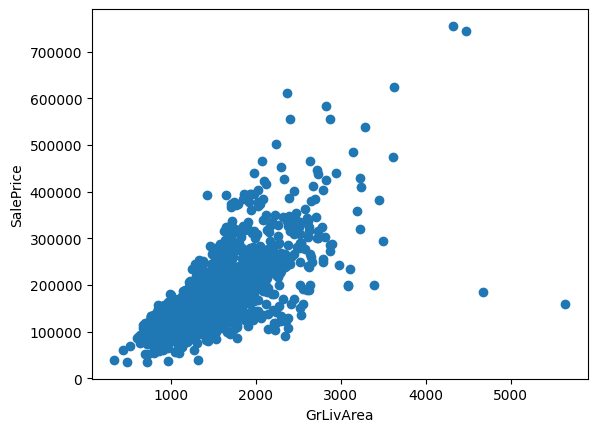

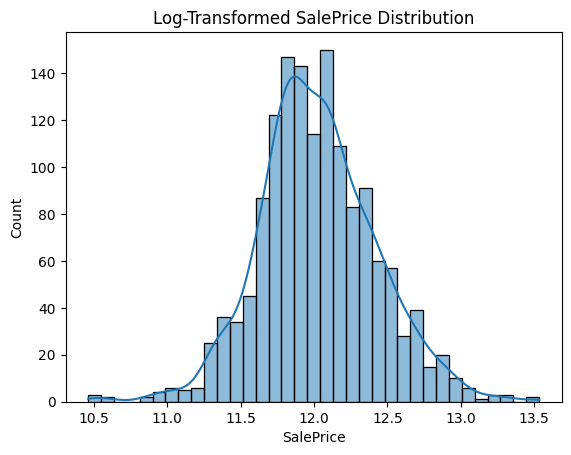

In [106]:
# 1. Missing Value Analysis & Filling
# Filling specific categorical features where NaN means 'None'
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'MasVnrType']
for col in none_cols:
    train_df[col] = train_df[col].fillna('None') # NaN represents the absence of the feature

# Filling numerical features with median or 0 as appropriate
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(train_df['LotFrontage'].median())
train_df['GarageArea'] = train_df['GarageArea'].fillna(0)

# --- Bulk Solution for remaining columns ---
# Fill remaining numerical columns with 0 (like MasVnrArea or GarageCars)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
train_df[numeric_cols] = train_df[numeric_cols].fillna(0)

# Fill remaining categorical columns with the most frequent value (Mode)
categorical_cols = train_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# 2. Outlier Removal
# Plotting GrLivArea vs SalePrice to identify outliers
plt.scatter(x=train_df['GrLivArea'], y=train_df['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

# Removing extreme outliers (e.g., houses with > 4000 sqft area but low price)
train_df = train_df.drop(train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index)

# train_df.info()

# 3. Data Transformation
# Log-transform the target variable to fix skewness
train_df["SalePrice"] = np.log1p(train_df["SalePrice"])

# Check the new distribution
sns.histplot(train_df['SalePrice'], kde=True)
plt.title('Log-Transformed SalePrice Distribution')
plt.show()

### **Task 3: Exploratory Data Analysis (EDA)**
* **Correlation Analysis**: Computing a correlation matrix for numerical features and using a heatmap to identify the top 5 features most strongly correlated with **SalePrice**.
* **Visual Exploration**: Creating a scatter plot to analyze the relationship between **GrLivArea** (ground living area) and **SalePrice**, with color coding by **OverallQual**.
* **Geographical Insights**: Visualizing the average **SalePrice** across different **Neighborhood** values to understand location-based pricing.

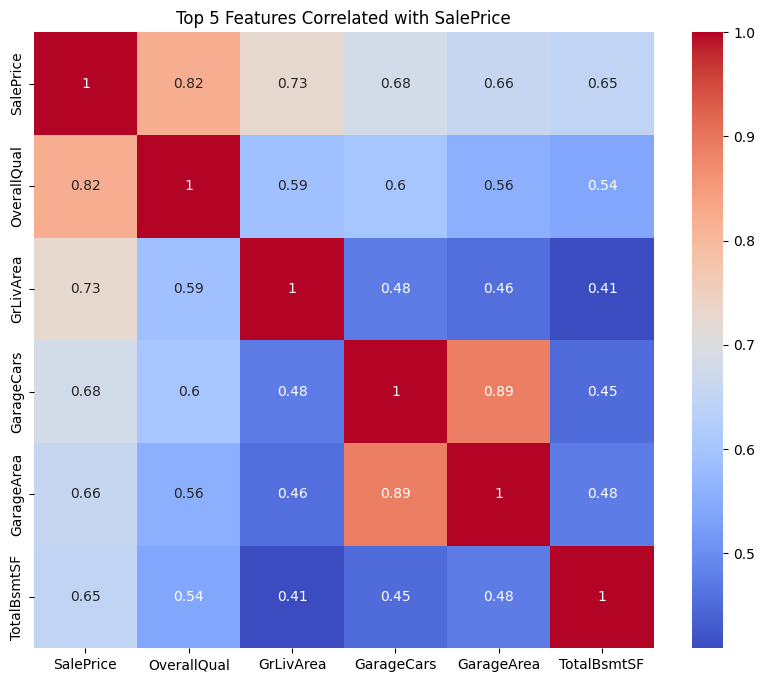

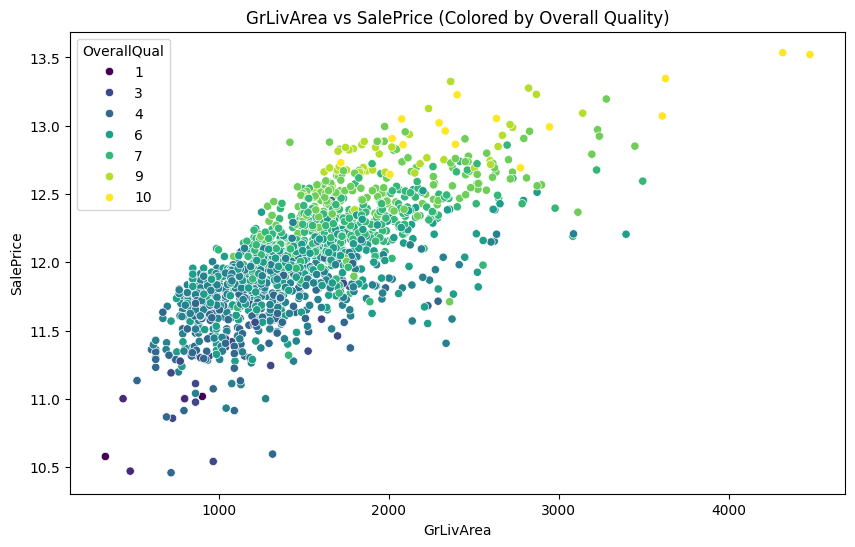

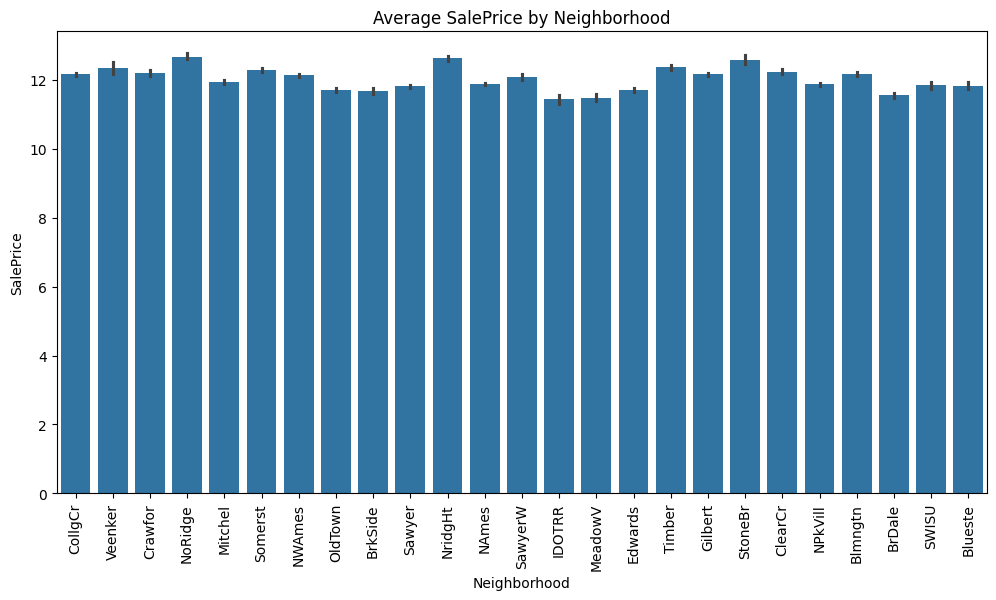

In [101]:
# 1. Correlation Analysis
# Compute correlation matrix for numerical features
corr_matrix = train_df.select_dtypes(include=[np.number]).corr()

# Get the top 5 features correlated with SalePrice
top_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(6).index
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[top_features].corr(), annot=True, cmap='coolwarm')
plt.title('Top 5 Features Correlated with SalePrice')
plt.show()

# 2. Visual Exploration
# Scatter plot between GrLivArea and SalePrice, colored by Overall Qual
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='GrLivArea', y='SalePrice', hue='OverallQual', palette='viridis')
plt.title('GrLivArea vs SalePrice (Colored by Overall Quality)')
plt.show()

# 3. Geographical Insights
# Average SalePrice across different neighborhoods
plt.figure(figsize=(12, 6))
sns.barplot(data=train_df, x='Neighborhood', y='SalePrice', estimator=np.mean)
plt.xticks(rotation=90)
plt.title('Average SalePrice by Neighborhood')
plt.show()

### **Task 4: Feature Engineering**
* **Feature Transformation**: Creating a new feature **TotalSF** by summing **TotalBsmtSF**, **1stFlrSF**, and **2ndFlrSF** to capture total living space.
* **Encoding Categorical Variables**:
    * Applying **Label Encoding** to ordinal features (e.g., **ExterQual**, **KitchenQual**) to preserve their natural ranking.
    * Applying **One-Hot Encoding** to nominal features (e.g., **Neighborhood**, **BldgType**) for model compatibility.
* **Processing Function**: Structuring transformations to ensure consistency between training and testing sets.

In [102]:
from sklearn.preprocessing import LabelEncoder

# 1. Feature Transformation
# Create TotalSF: Total Square Footage of the house
train_df['TotalSF'] = train_df['TotalBsmtSF'] + train_df['1stFlrSF'] + train_df['2ndFlrSF']

# 2. Encoding Categorical Variables
# Label Encoding for ordinal features (Ranking preserved)
ordinal_features = ['ExterQual', 'KitchenQual', 'HeatingQC']
label_enc = LabelEncoder()
for col in ordinal_features:
    if col in train_df.columns:
        train_df[col] = label_enc.fit_transform(train_df[col].astype(str))

# One-Hot Encoding for nominal features (Categories)
nominal_features = ['Neighborhood', 'BldgType', 'HouseStyle']
train_df = pd.get_dummies(train_df, columns=nominal_features)

print("Feature Engineering completed successfully.")
print(f"New dataset shape: {train_df.shape}")

Feature Engineering completed successfully.
New dataset shape: (1458, 117)


In [103]:
# Final Step: Combining all logic into a single function for consistency
def apply_preprocessing(df):
    data = df.copy()

    # Fill categorical NaNs (PoolQC, MiscFeature, Alley, Fence, etc.)
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
    for col in none_cols:
        if col in data.columns:
            data[col] = data[col].fillna('None')

    # Fill numerical NaNs (LotFrontage)
    if 'LotFrontage' in data.columns:
        data['LotFrontage'] = data['LotFrontage'].fillna(data['LotFrontage'].median())

    # Create the engineered feature: TotalSF
    if all(col in data.columns for col in ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']):
        data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']

    # One-Hot Encoding for categorical features
    cols_to_encode = ['Neighborhood', 'BldgType']
    data = pd.get_dummies(data, columns=[c for c in cols_to_encode if c in data.columns])

    return data

# Now apply to both datasets in one step
train_ready = apply_preprocessing(train_df)
test_ready = apply_preprocessing(test_df)